Dtypes after encoding:
Age                    int64
Gender                 int64
Hormonal Changes       int64
Family History         int64
Race/Ethnicity         int64
Body Weight            int64
Calcium Intake         int64
Vitamin D Intake       int64
Physical Activity      int64
Smoking                int64
Alcohol Consumption    int64
Medical Conditions     int64
Medications            int64
Prior Fractures        int64
Osteoporosis           int64
Age_Group              int64
Risk_Score             int64
dtype: object



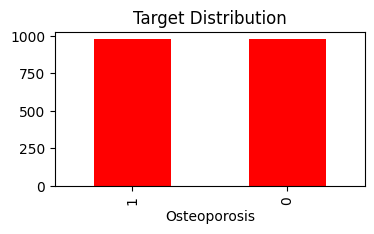

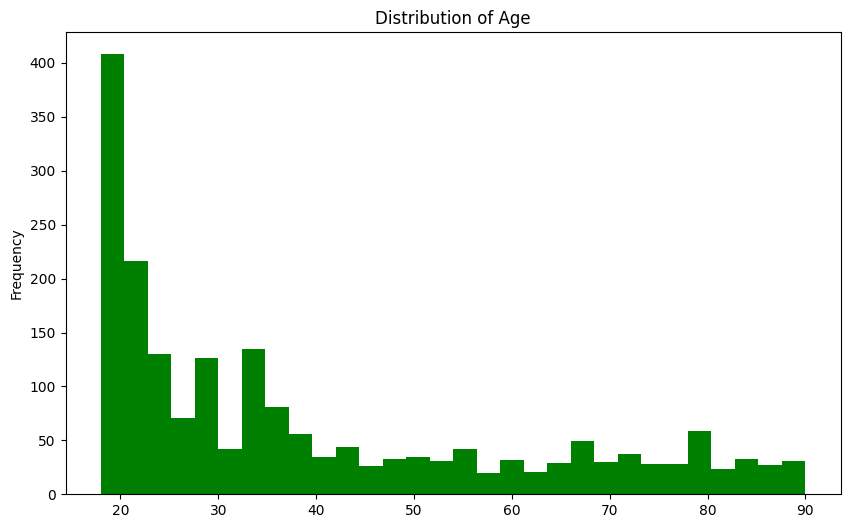

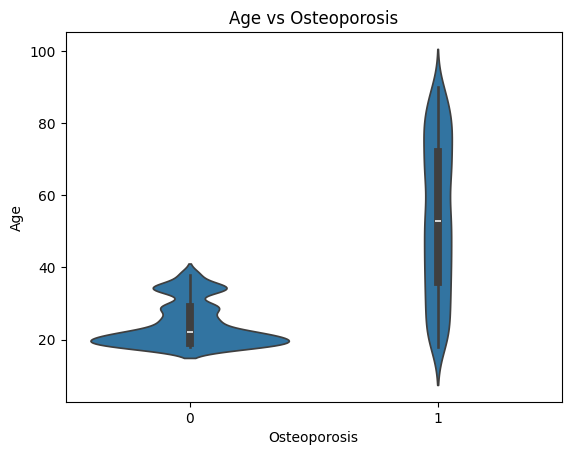


MODEL: Logistic Regression

Accuracy: 83.93%

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.91      0.85       196
           1       0.89      0.77      0.83       196

    accuracy                           0.84       392
   macro avg       0.85      0.84      0.84       392
weighted avg       0.85      0.84      0.84       392



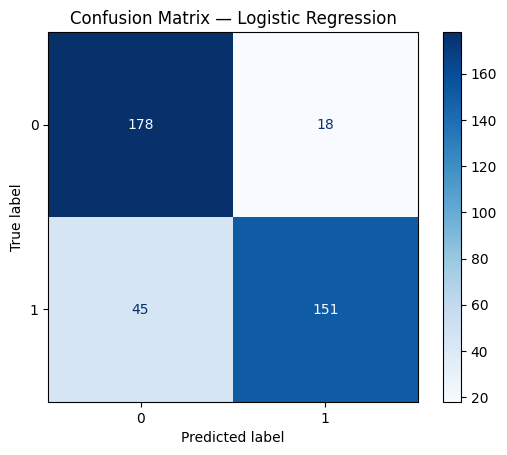

Cross-Val Accuracy: 83.20%
CV Std Dev       : 1.59%

MODEL: Decision Tree

Accuracy: 83.67%

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.83      0.84       196
           1       0.83      0.85      0.84       196

    accuracy                           0.84       392
   macro avg       0.84      0.84      0.84       392
weighted avg       0.84      0.84      0.84       392



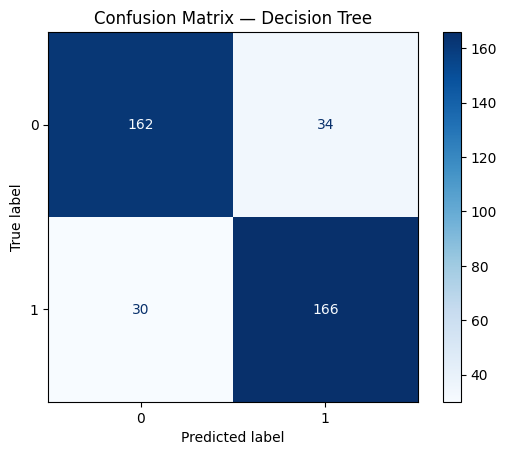

Cross-Val Accuracy: 84.53%
CV Std Dev       : 3.58%

MODEL: Random Forest

Accuracy: 87.24%

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.96      0.88       196
           1       0.95      0.79      0.86       196

    accuracy                           0.87       392
   macro avg       0.88      0.87      0.87       392
weighted avg       0.88      0.87      0.87       392



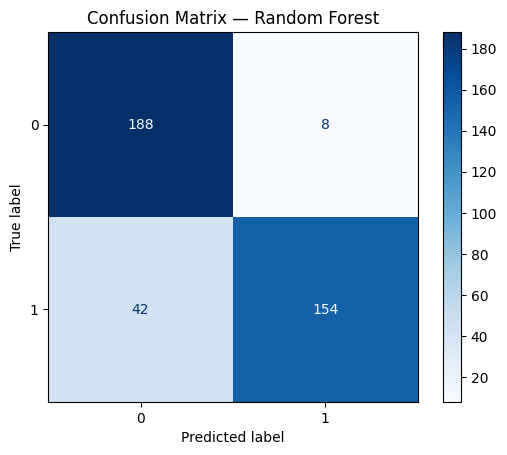

Cross-Val Accuracy: 86.77%
CV Std Dev       : 1.08%

MODEL: Gradient Boosting

Accuracy: 90.56%

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.99      0.91       196
           1       0.99      0.82      0.90       196

    accuracy                           0.91       392
   macro avg       0.92      0.91      0.90       392
weighted avg       0.92      0.91      0.90       392



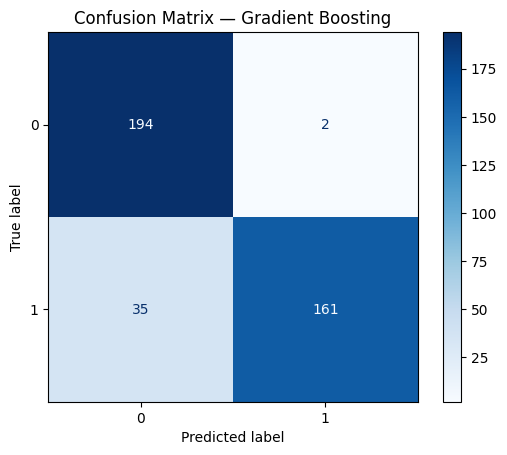

Cross-Val Accuracy: 91.32%
CV Std Dev       : 0.70%

FINAL COMPARISON TABLE:
          Algorithm  Test Accuracy (%)  CV Mean (%)  CV Std (%)
  Gradient Boosting              90.56        91.32        0.70
      Random Forest              87.24        86.77        1.08
Logistic Regression              83.93        83.20        1.59
      Decision Tree              83.67        84.53        3.58


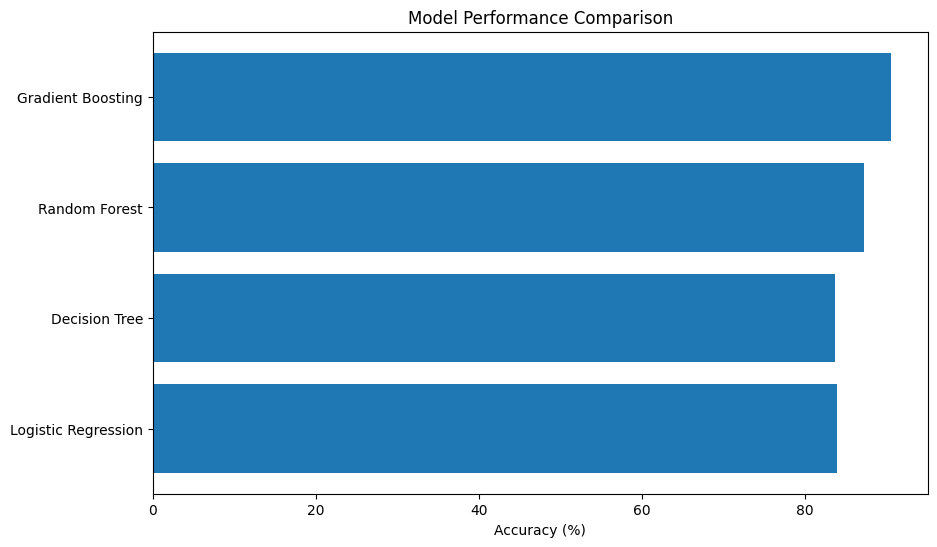


Best Parameters: {'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 5, 'n_estimators': 200, 'subsample': 1.0}

Tuned Accuracy: 91.07%
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       196
           1       1.00      0.82      0.90       196

    accuracy                           0.91       392
   macro avg       0.92      0.91      0.91       392
weighted avg       0.92      0.91      0.91       392



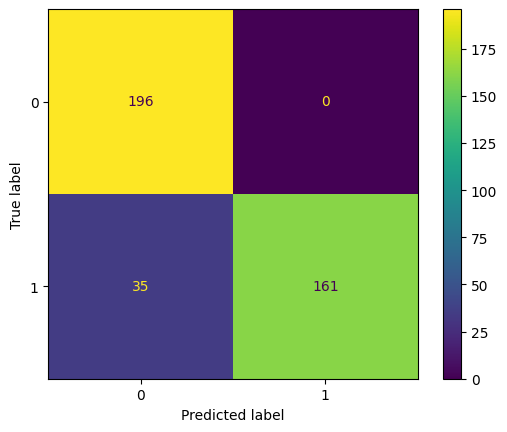

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# =============================================================================
# 1. LOAD & CLEAN
# =============================================================================
df = pd.read_csv('/content/osteoporosis.csv')

Patient_ID = df["Id"]
df = df.drop(columns="Id")

df = df.fillna("None")

# =============================================================================
# 2. FEATURE ENGINEERING
# =============================================================================
df['Age_Group'] = pd.cut(
    df['Age'],
    bins=[0, 30, 50, 70, 100],
    labels=[0, 1, 2, 3]
).astype(int)

df['Risk_Score'] = (
    (df['Smoking']           == 'Yes').astype(int) +
    (df['Family History']    == 'Yes').astype(int) +
    (df['Prior Fractures']   == 'Yes').astype(int) +
    (df['Calcium Intake']    == 'Low').astype(int) +
    (df['Vitamin D Intake']  == 'Insufficient').astype(int) +
    (df['Physical Activity'] == 'Sedentary').astype(int) +
    (df['Body Weight']       == 'Underweight').astype(int)
)

# =============================================================================
# 3. ENCODING
# =============================================================================
le_dict = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

print("Dtypes after encoding:")
print(df.dtypes)
print()

# =============================================================================
# 4. EDA
# =============================================================================
plt.figure(figsize=(4, 2))
df['Osteoporosis'].value_counts().plot(kind='bar', color='red')
plt.title("Target Distribution")
plt.show()

plt.figure(figsize=(10, 6))
df['Age'].plot(kind="hist", bins=30, color="green")
plt.title("Distribution of Age")
plt.show()

sns.violinplot(data=df, x='Osteoporosis', y='Age')
plt.title("Age vs Osteoporosis")
plt.show()

# =============================================================================
# 5. TRAIN TEST SPLIT
# =============================================================================
X = df.drop(columns='Osteoporosis')
y = df['Osteoporosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=24, stratify=y
)

# =============================================================================
# 🔥 IMPORTANT: DEFINE MODELS (FIXED BUG)
# =============================================================================
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000),
    "Decision Tree"       : DecisionTreeClassifier(random_state=24),
    "Random Forest"       : RandomForestClassifier(random_state=24),
    "Gradient Boosting"   : GradientBoostingClassifier(random_state=24)
}

# =============================================================================
# 6. FULL MODEL EVALUATION
# =============================================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=24)
results = []

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"MODEL: {name}")
    print(f"{'='*50}")

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds) * 100
    print(f"\nAccuracy: {acc:.2f}%")

    print("\nClassification Report:")
    print(classification_report(y_test, preds))

    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=model.classes_)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix — {name}")
    plt.show()

    cv_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    print(f"Cross-Val Accuracy: {cv_scores.mean()*100:.2f}%")
    print(f"CV Std Dev       : {cv_scores.std()*100:.2f}%")

    results.append([
        name,
        round(acc, 2),
        round(cv_scores.mean()*100, 2),
        round(cv_scores.std()*100, 2)
    ])

# Results Table
results_df = pd.DataFrame(results, columns=[
    'Algorithm', 'Test Accuracy (%)', 'CV Mean (%)', 'CV Std (%)'
])

print("\nFINAL COMPARISON TABLE:")
print(results_df.sort_values('Test Accuracy (%)', ascending=False).to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(results_df['Algorithm'], results_df['Test Accuracy (%)'])
plt.xlabel('Accuracy (%)')
plt.title('Model Performance Comparison')
plt.show()

# =============================================================================
# 7. HYPERPARAMETER TUNING
# =============================================================================
param_grid = {
    'n_estimators'    : [100, 200],
    'max_depth'       : [2, 3],
    'learning_rate'   : [0.05, 0.1],
    'subsample'       : [0.8, 1.0],
    'min_samples_leaf': [5, 10],
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=24),
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")

# =============================================================================
# 8. FINAL MODEL
# =============================================================================
best_gbm = grid_search.best_estimator_
preds = best_gbm.predict(X_test)

print(f"\nTuned Accuracy: {accuracy_score(y_test, preds)*100:.2f}%")
print(classification_report(y_test, preds))

cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(cm).plot()
plt.show()

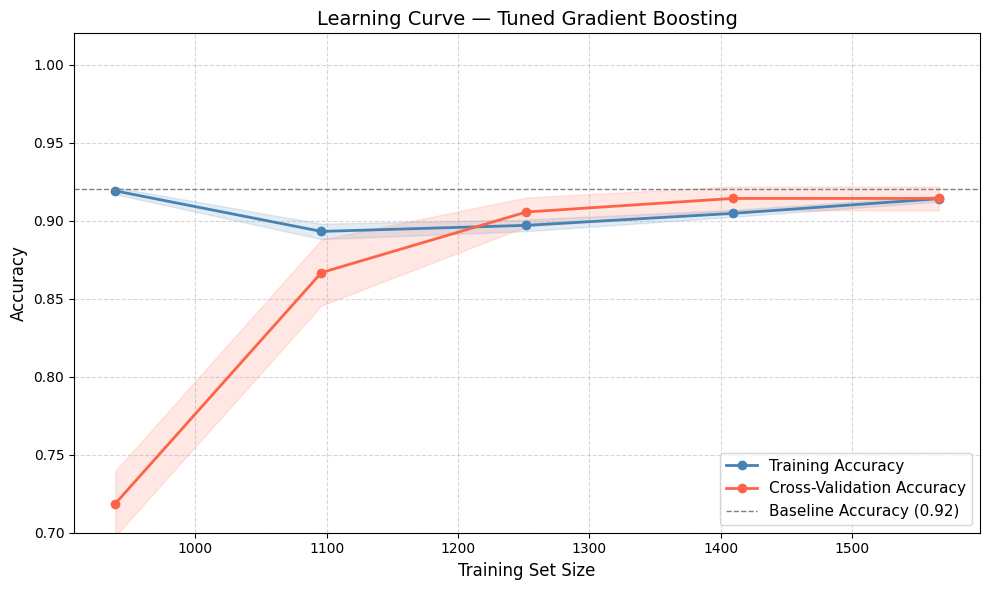

Training Accuracy   (at full data): 91.40% ± 0.19%
Validation Accuracy (at full data): 91.42% ± 0.76%
Train-Val Gap                      : -0.02%

✓ Small gap and high validation accuracy — model generalises well.


In [5]:
from sklearn.model_selection import learning_curve
import numpy as np

# =============================================================================
# LEARNING CURVE — Tuned Gradient Boosting Model
# =============================================================================
# Uses the best_gbm and X_train/y_train already defined above.
# If running standalone, fit best_gbm first via the GridSearchCV block.

train_sizes, train_scores, val_scores = learning_curve(
    estimator   = best_gbm,
    X           = X,
    y           = y,
    cv          = StratifiedKFold(n_splits=5, shuffle=True, random_state=24),
    train_sizes = np.linspace(0.1, 1.0, 10),   # 10 points from 10% to 100% of data
    scoring     = 'accuracy',
    n_jobs      = -1
)

# Mean and std across folds
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

# =============================================================================
# PLOT
# =============================================================================
plt.figure(figsize=(10, 6))

# Training score
plt.plot(train_sizes, train_mean, 'o-', color='steelblue',
         linewidth=2, label='Training Accuracy')
plt.fill_between(train_sizes,
                 train_mean - train_std,
                 train_mean + train_std,
                 alpha=0.15, color='steelblue')

# Validation score
plt.plot(train_sizes, val_mean, 'o-', color='tomato',
         linewidth=2, label='Cross-Validation Accuracy')
plt.fill_between(train_sizes,
                 val_mean - val_std,
                 val_mean + val_std,
                 alpha=0.15, color='tomato')

# Reference line at baseline accuracy
plt.axhline(y=0.92, color='gray', linestyle='--', linewidth=1,
            label='Baseline Accuracy (0.92)')

plt.title('Learning Curve — Tuned Gradient Boosting', fontsize=14)
plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.ylim(0.70, 1.02)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# =============================================================================
# INTERPRETATION PRINTOUT
# =============================================================================
gap = train_mean[-1] - val_mean[-1]

print(f"Training Accuracy   (at full data): {train_mean[-1]*100:.2f}% ± {train_std[-1]*100:.2f}%")
print(f"Validation Accuracy (at full data): {val_mean[-1]*100:.2f}% ± {val_std[-1]*100:.2f}%")
print(f"Train-Val Gap                      : {gap*100:.2f}%")
print()
if gap > 0.10:
    print("⚠ Large gap — model may be OVERFITTING. Consider reducing max_depth or increasing min_samples_leaf.")
elif val_mean[-1] < 0.85:
    print("⚠ Low validation accuracy — model may be UNDERFITTING. Consider more estimators or higher complexity.")
else:
    print("✓ Small gap and high validation accuracy — model generalises well.")

In [ ]:
import pandas as pd
import numpy as np
import pickle
import gradio as gr
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier

# =============================================================================
# STEP 1: TRAIN & SAVE MODEL  (run once — skip if model.pkl already exists)
# =============================================================================

def train_and_save():
    df = pd.read_csv('/content/osteoporosis.csv')
    df = df.drop(columns="Id")
    df = df.fillna("None")

    # Feature engineering
    df['Age_Group'] = pd.cut(df['Age'], bins=[0,30,50,70,100], labels=[0,1,2,3]).astype(int)
    df['Risk_Score'] = (
        (df['Smoking']           == 'Yes').astype(int) +
        (df['Family History']    == 'Yes').astype(int) +
        (df['Prior Fractures']   == 'Yes').astype(int) +
        (df['Calcium Intake']    == 'Low').astype(int) +
        (df['Vitamin D Intake']  == 'Insufficient').astype(int) +
        (df['Physical Activity'] == 'Sedentary').astype(int) +
        (df['Body Weight']       == 'Underweight').astype(int)
    )

    # Label encode
    le_dict = {}
    for col in df.select_dtypes(include='object').columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        le_dict[col] = le

    X = df.drop(columns='Osteoporosis')
    y = df['Osteoporosis']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=24, stratify=y
    )

    # Best params from GridSearchCV (hard-coded to avoid re-running every time)
    best_gbm = GradientBoostingClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.85,
        min_samples_leaf=10,
        random_state=24
    )
    best_gbm.fit(X_train, y_train)

    # Save model + encoders + feature names
    with open("model.pkl", "wb") as f:
        pickle.dump({
            "model"    : best_gbm,
            "le_dict"  : le_dict,
            "features" : list(X.columns)
        }, f)

    print("✓ Model saved to model.pkl")
    return best_gbm, le_dict, list(X.columns)


# =============================================================================
# STEP 2: LOAD MODEL
# =============================================================================

import os
if os.path.exists("model.pkl"):
    with open("model.pkl", "rb") as f:
        saved = pickle.load(f)
    model    = saved["model"]
    le_dict  = saved["le_dict"]
    features = saved["features"]
    print("✓ Model loaded from model.pkl")
else:
    model, le_dict, features = train_and_save()


# =============================================================================
# STEP 3: PREDICTION FUNCTION
# =============================================================================

def predict_osteoporosis(
    age, gender, hormonal_changes, family_history, race,
    body_weight, calcium_intake, vitamin_d, physical_activity,
    smoking, alcohol, medical_conditions, medications, prior_fractures
):
    # Build raw input dict (same column names as training data)
    raw = {
        "Age"                : age,
        "Gender"             : gender,
        "Hormonal Changes"   : hormonal_changes,
        "Family History"     : family_history,
        "Race/Ethnicity"     : race,
        "Body Weight"        : body_weight,
        "Calcium Intake"     : calcium_intake,
        "Vitamin D Intake"   : vitamin_d,
        "Physical Activity"  : physical_activity,
        "Smoking"            : smoking,
        "Alcohol Consumption": alcohol if alcohol else "None",
        "Medical Conditions" : medical_conditions if medical_conditions else "None",
        "Medications"        : medications if medications else "None",
        "Prior Fractures"    : prior_fractures,
    }

    input_df = pd.DataFrame([raw])

    # Feature engineering — must mirror training exactly
    input_df['Age_Group'] = pd.cut(
        input_df['Age'], bins=[0,30,50,70,100], labels=[0,1,2,3]
    ).astype(int)

    input_df['Risk_Score'] = (
        (input_df['Smoking']           == 'Yes').astype(int) +
        (input_df['Family History']    == 'Yes').astype(int) +
        (input_df['Prior Fractures']   == 'Yes').astype(int) +
        (input_df['Calcium Intake']    == 'Low').astype(int) +
        (input_df['Vitamin D Intake']  == 'Insufficient').astype(int) +
        (input_df['Physical Activity'] == 'Sedentary').astype(int) +
        (input_df['Body Weight']       == 'Underweight').astype(int)
    )

    # Encode categoricals using saved label encoders
    for col, le in le_dict.items():
        if col in input_df.columns:
            val = input_df[col].astype(str).iloc[0]
            # Handle unseen labels gracefully
            if val in le.classes_:
                input_df[col] = le.transform([val])
            else:
                input_df[col] = le.transform([le.classes_[0]])

    # Align columns to training feature order
    input_df = input_df[features]

    # Predict
    prob       = model.predict_proba(input_df)[0]
    prediction = model.predict(input_df)[0]
    confidence = prob[prediction] * 100

    if prediction == 1:
        label  = "⚠️ HIGH RISK — Osteoporosis Detected"
        detail = (
            f"The model predicts this patient is at **high risk** of osteoporosis "
            f"with **{confidence:.1f}% confidence**.\n\n"
            "**Recommended actions:**\n"
            "- Consult a healthcare provider for a bone density scan (DEXA)\n"
            "- Review calcium and vitamin D intake\n"
            "- Consider weight-bearing exercise\n"
            "- Discuss medications with your doctor"
        )
    else:
        label  = "✅ LOW RISK — No Osteoporosis Detected"
        detail = (
            f"The model predicts this patient is at **low risk** of osteoporosis "
            f"with **{confidence:.1f}% confidence**.\n\n"
            "**Preventive tips:**\n"
            "- Maintain adequate calcium and vitamin D levels\n"
            "- Stay physically active\n"
            "- Avoid smoking and excessive alcohol\n"
            "- Schedule regular check-ups after age 50"
        )

    risk_breakdown = (
        f"**Risk Score:** {int(input_df['Risk_Score'].iloc[0])} / 7 lifestyle risk factors\n\n"
        f"**Probability — No Osteoporosis:** {prob[0]*100:.1f}%\n\n"
        f"**Probability — Osteoporosis:**    {prob[1]*100:.1f}%"
    )

    return label, detail, risk_breakdown


# =============================================================================
# STEP 4: GRADIO INTERFACE
# =============================================================================

with gr.Blocks(
    title="Osteoporosis Risk Predictor",
    theme=gr.themes.Soft(
        primary_hue="blue",
        secondary_hue="indigo",
        neutral_hue="slate"
    ),
    css="""
        .result-box  { border-radius: 12px; padding: 16px; }
        .header-text { text-align: center; margin-bottom: 8px; }
        footer        { display: none !important; }
    """
) as demo:

    # ── Header ────────────────────────────────────────────────────────────────
    gr.Markdown(
        """
        # 🦴 Osteoporosis Risk Predictor
        ### Machine Learning-Based Clinical Decision Support Tool
        Fill in the patient's lifestyle and clinical details below.
        The Gradient Boosting model (91%+ accuracy) will assess osteoporosis risk.

        > ⚠️ *This tool is for research purposes only and does not replace clinical diagnosis.*
        """,
        elem_classes="header-text"
    )

    # ── Input Section ─────────────────────────────────────────────────────────
    with gr.Row():

        # Left column
        with gr.Column():
            gr.Markdown("### 👤 Patient Demographics")
            age = gr.Slider(
                minimum=18, maximum=90, value=45, step=1,
                label="Age"
            )
            gender = gr.Radio(
                choices=["Male", "Female"],
                value="Female",
                label="Gender"
            )
            race = gr.Dropdown(
                choices=["African American", "Asian", "Caucasian"],
                value="Caucasian",
                label="Race / Ethnicity"
            )
            hormonal_changes = gr.Radio(
                choices=["Normal", "Postmenopausal"],
                value="Normal",
                label="Hormonal Changes"
            )
            family_history = gr.Radio(
                choices=["Yes", "No"],
                value="No",
                label="Family History of Osteoporosis"
            )

        # Right column
        with gr.Column():
            gr.Markdown("### 🏃 Lifestyle Factors")
            body_weight = gr.Radio(
                choices=["Normal", "Underweight"],
                value="Normal",
                label="Body Weight"
            )
            physical_activity = gr.Radio(
                choices=["Active", "Sedentary"],
                value="Active",
                label="Physical Activity Level"
            )
            calcium_intake = gr.Radio(
                choices=["Adequate", "Low"],
                value="Adequate",
                label="Calcium Intake"
            )
            vitamin_d = gr.Radio(
                choices=["Sufficient", "Insufficient"],
                value="Sufficient",
                label="Vitamin D Intake"
            )
            smoking = gr.Radio(
                choices=["Yes", "No"],
                value="No",
                label="Smoking"
            )
            alcohol = gr.Radio(
                choices=["Moderate", "None"],
                value="None",
                label="Alcohol Consumption"
            )

    with gr.Row():
        with gr.Column():
            gr.Markdown("### 🏥 Medical History")
            medical_conditions = gr.Dropdown(
                choices=["None", "Hyperthyroidism", "Rheumatoid Arthritis"],
                value="None",
                label="Medical Conditions"
            )
            medications = gr.Dropdown(
                choices=["None", "Corticosteroids"],
                value="None",
                label="Current Medications"
            )
            prior_fractures = gr.Radio(
                choices=["Yes", "No"],
                value="No",
                label="Prior Fractures"
            )

    # ── Predict Button ────────────────────────────────────────────────────────
    predict_btn = gr.Button("🔍 Predict Osteoporosis Risk", variant="primary", size="lg")

    # ── Output Section ────────────────────────────────────────────────────────
    gr.Markdown("---")
    gr.Markdown("### 📊 Prediction Results")

    with gr.Row():
        with gr.Column():
            result_label  = gr.Markdown(label="Prediction")
            result_detail = gr.Markdown(label="Details")
        with gr.Column():
            result_risk   = gr.Markdown(label="Risk Breakdown")

    # ── Examples ──────────────────────────────────────────────────────────────
    gr.Markdown("---")
    gr.Examples(
        examples=[
            [69, "Female", "Postmenopausal", "Yes", "Asian",    "Underweight", "Low",      "Insufficient", "Sedentary", "Yes", "Moderate", "Rheumatoid Arthritis", "Corticosteroids", "Yes"],
            [32, "Male",   "Normal",         "No",  "Caucasian","Normal",      "Adequate", "Sufficient",   "Active",    "No",  "None",     "None",                 "None",            "No"],
            [55, "Female", "Postmenopausal", "Yes", "Caucasian","Normal",      "Low",      "Insufficient", "Sedentary", "No",  "None",     "Hyperthyroidism",      "Corticosteroids", "No"],
        ],
        inputs=[
            age, gender, hormonal_changes, family_history, race,
            body_weight, calcium_intake, vitamin_d, physical_activity,
            smoking, alcohol, medical_conditions, medications, prior_fractures
        ],
        label="Try Example Patients"
    )

    # ── Wire up button ────────────────────────────────────────────────────────
    predict_btn.click(
        fn      = predict_osteoporosis,
        inputs  = [
            age, gender, hormonal_changes, family_history, race,
            body_weight, calcium_intake, vitamin_d, physical_activity,
            smoking, alcohol, medical_conditions, medications, prior_fractures
        ],
        outputs = [result_label, result_detail, result_risk]
    )


# =============================================================================
# STEP 5: LAUNCH
# =============================================================================
if __name__ == "__main__":
    demo.launch(
        share       = True,    # set False if running locally without public link
        server_name = "0.0.0.0",
        server_port = 7860,
        show_error  = True
    )

✓ Model saved to model.pkl
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7655be5e93000067fc.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
